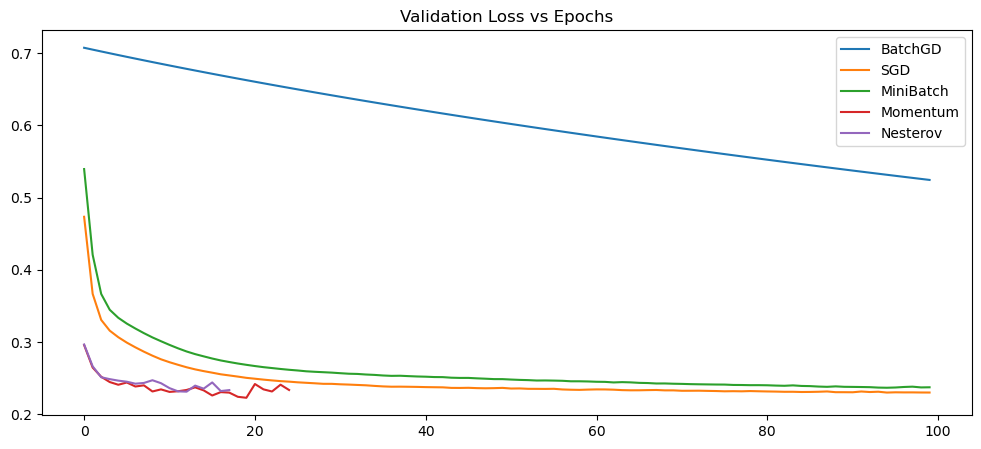

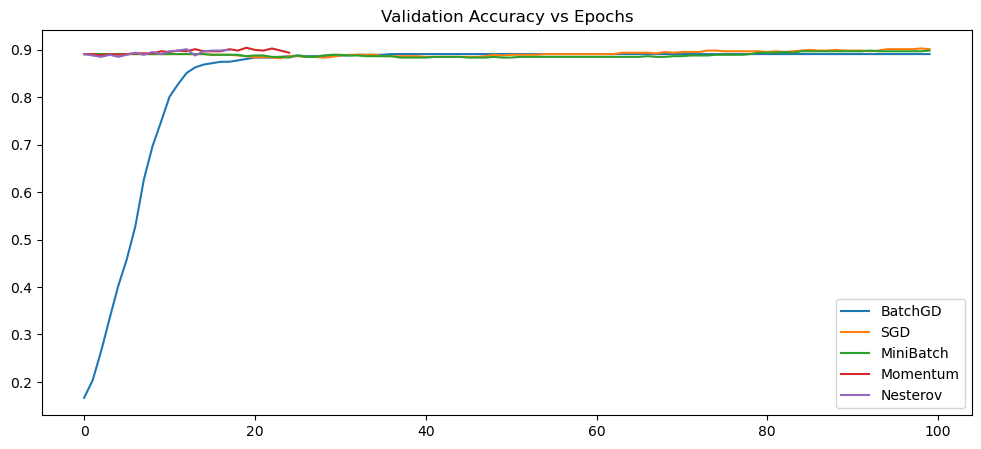

SGD with lr=0.001, final val acc=0.8893805309734514
SGD with lr=0.01, final val acc=0.8967551622418879
SGD with lr=0.1, final val acc=0.8938053097345132
Momentum with m=0.5, final val acc=0.8938053097345132
Momentum with m=0.9, final val acc=0.8982300884955752
Test Accuracy: 0.8880706921944035
Precision: 0.5172413793103449
Recall: 0.38461538461538464
F1-score: 0.4411764705882353
Confusion Matrix:
 [[573  28]
 [ 48  30]]


In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
df = pd.read_csv(r"C:\Users\23adsb48\Documents\bank\bank.csv", sep=";")
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('y')
numerical_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded = encoder.fit_transform(df[categorical_cols])
scaler = StandardScaler()
scaled = scaler.fit_transform(df[numerical_cols])
X = np.hstack([scaled, encoded])
y = (df['y'] == 'yes').astype(int).values
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
train_data = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
val_data = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))
test_data = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))
class BankNN(nn.Module):
    def __init__(self, input_dim):
        super(BankNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.drop1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 64)
        self.drop2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(64, 1)
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.drop1(x)
        x = torch.relu(self.fc2(x))
        x = self.drop2(x)
        return torch.sigmoid(self.fc3(x))
def train_model(optimizer_name, optimizer_fn, batch_size=32, lr=0.01, momentum=0.9):
    model = BankNN(X_train.shape[1])
    criterion = nn.BCELoss()
    optimizer = optimizer_fn(model.parameters(), lr=lr)
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
    best_val_loss = np.inf
    patience, patience_counter = 5, 0
    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    start_time = time.time()
    for epoch in range(100):
        model.train()
        train_losses, train_preds, train_targets = [], [], []
        for xb, yb in train_loader:
            optimizer.zero_grad()
            outputs = model(xb).squeeze()
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            train_preds.extend((outputs.detach().numpy()>0.5).astype(int))
            train_targets.extend(yb.numpy())
        train_acc = accuracy_score(train_targets, train_preds)
        val_losses, val_preds, val_targets = [], [], []
        model.eval()
        with torch.no_grad():
            for xb, yb in val_loader:
                outputs = model(xb).squeeze()
                loss = criterion(outputs, yb)
                val_losses.append(loss.item())
                val_preds.extend((outputs.numpy()>0.5).astype(int))
                val_targets.extend(yb.numpy())
        val_acc = accuracy_score(val_targets, val_preds)
        history['train_loss'].append(np.mean(train_losses))
        history['val_loss'].append(np.mean(val_losses))
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        if np.mean(val_losses) < best_val_loss:
            best_val_loss = np.mean(val_losses)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    total_time = time.time() - start_time
    return model, history, total_time
optimizers = {
    "BatchGD": lambda params, lr: optim.SGD(params, lr=lr),
    "SGD": lambda params, lr: optim.SGD(params, lr=lr),
    "MiniBatch": lambda params, lr: optim.SGD(params, lr=lr),
    "Momentum": lambda params, lr: optim.SGD(params, lr=lr, momentum=0.9),
    "Nesterov": lambda params, lr: optim.SGD(params, lr=lr, momentum=0.9, nesterov=True)
}
results = {}
for name, opt_fn in optimizers.items():
    batch_size = len(train_data) if name=="BatchGD" else 32
    model, history, t = train_model(name, opt_fn, batch_size=batch_size)
    results[name] = (model, history, t)
plt.figure(figsize=(12,5))
for name in results:
    plt.plot(results[name][1]['val_loss'], label=name)
plt.title("Validation Loss vs Epochs")
plt.legend()
plt.show()
plt.figure(figsize=(12,5))
for name in results:
    plt.plot(results[name][1]['val_acc'], label=name)
plt.title("Validation Accuracy vs Epochs")
plt.legend()
plt.show()
batch_sizes = [16, 64, 256]
batch_results = {}
for bs in batch_sizes:
    model, history, t = train_model("MiniBatch", optimizers["MiniBatch"], batch_size=bs)
    batch_results[bs] = (model, history, t)
for lr in [0.001, 0.01, 0.1]:
    model, history, t = train_model("SGD", optimizers["SGD"], lr=lr)
    print(f"SGD with lr={lr}, final val acc={history['val_acc'][-1]}")
for m in [0.5, 0.9]:
    model, history, t = train_model("Momentum", lambda p, lr: optim.SGD(p, lr=lr, momentum=m))
    print(f"Momentum with m={m}, final val acc={history['val_acc'][-1]}")
best_model = results["Nesterov"][0]
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)
test_preds, test_targets = [], []
best_model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        outputs = best_model(xb).squeeze()
        test_preds.extend((outputs.numpy()>0.5).astype(int))
        test_targets.extend(yb.numpy())
acc = accuracy_score(test_targets, test_preds)
prec = precision_score(test_targets, test_preds)
rec = recall_score(test_targets, test_preds)
f1 = f1_score(test_targets, test_preds)
cm = confusion_matrix(test_targets, test_preds)
print("Test Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)
print("Confusion Matrix:\n", cm)